In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Cargar el Dataset
products = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_products_dataset.csv")
orders = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_orders_dataset.csv")
order_items = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_order_items_dataset.csv")
reviews = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_order_reviews_dataset.csv")
payments = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_order_payments_dataset.csv")
customers = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\olist_customers_dataset.csv")
translation = pd.read_csv(
    r"C:\Users\bella\OneDrive\Escritorio\DATA SCIENCE\PF_Data_science\data\raw\product_category_name_translation.csv")

se priorizarán las tablas directamente relacionadas con el comportamiento transaccional, el catálogo de productos, las reseñas, los pagos y la información de clientes, complementadas con la tabla de traducción de categorías para mejorar la interpretación del negocio. Las tablas de vendedores y geolocalización serán consideradas de manera secundaria, dado que no son críticas para el MVP inicial del sistema de recomendación.

In [4]:
# Diccionario de Tablas
tablas = {
    "products": products,
    "orders": orders,
    "order_items": order_items,
    "reviews": reviews,
    "payments": payments,
    "customers": customers,
    "translation": translation
}

In [5]:
for nombre, df in tablas.items():
    print(f"\n--- {nombre.upper()} ---")
    print("Filas y columnas:", df.shape)
    print(df.head(3))


--- PRODUCTS ---
Filas y columnas: (32951, 9)
                         product_id product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5            perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                 artes   
2  96bd76ec8810374ed1b65e291975717f         esporte_lazer   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0               30.0               18.0              20.0  
2             154.0               18.0                9.0              15.0  

--- ORDERS ---
Filas y columnas: (99441, 8)
                           order_id                   

In [6]:
for nombre, df in tablas.items():
    print(f"\n--- COLUMNAS DE {nombre.upper()} ---")
    print(df.columns.tolist())


--- COLUMNAS DE PRODUCTS ---
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

--- COLUMNAS DE ORDERS ---
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

--- COLUMNAS DE ORDER_ITEMS ---
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

--- COLUMNAS DE REVIEWS ---
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

--- COLUMNAS DE PAYMENTS ---
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

--- COLUMNAS DE CUSTOMERS ---
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'custom

In [7]:
for nombre, df in tablas.items():
    print(f"\n--- INFO DE {nombre.upper()} ---")
    print(df.info())


--- INFO DE PRODUCTS ---
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB
None

--- INFO DE ORDERS ---
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------       

In [8]:
for nombre, df in tablas.items():
    print(f"\n--- {nombre.upper()} ---")
    print("Dimensiones:", df.shape)
    print("Columnas:", df.columns.tolist())
    display(df.head(3))


--- PRODUCTS ---
Dimensiones: (32951, 9)
Columnas: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



--- ORDERS ---
Dimensiones: (99441, 8)
Columnas: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



--- ORDER_ITEMS ---
Dimensiones: (112650, 7)
Columnas: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


...

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71



--- CUSTOMERS ---
Dimensiones: (99441, 5)
Columnas: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



--- TRANSLATION ---
Dimensiones: (71, 2)
Columnas: ['product_category_name', 'product_category_name_english']


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [9]:
for nombre, df in tablas.items():
    print(f"\n--- NULOS EN {nombre.upper()} ---")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    print(nulos if not nulos.empty else "No hay nulos")


--- NULOS EN PRODUCTS ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

--- NULOS EN ORDERS ---
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

--- NULOS EN ORDER_ITEMS ---
No hay nulos

--- NULOS EN REVIEWS ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- NULOS EN PAYMENTS ---
No hay nulos

--- NULOS EN CUSTOMERS ---
No hay nulos

--- NULOS EN TRANSLATION ---
No hay nulos


In [10]:
for nombre, df in tablas.items():
    print(f"{nombre}: duplicados totales = {df.duplicated().sum()}")

products: duplicados totales = 0
orders: duplicados totales = 0
order_items: duplicados totales = 0
reviews: duplicados totales = 0
payments: duplicados totales = 0
customers: duplicados totales = 0
translation: duplicados totales = 0


In [11]:
print("Duplicados product_id en products:", products["product_id"].duplicated().sum())
print("Duplicados order_id en orders:", orders["order_id"].duplicated().sum())
print("Duplicados customer_id en customers:", customers["customer_id"].duplicated().sum())

Duplicados product_id en products: 0
Duplicados order_id en orders: 0
Duplicados customer_id en customers: 0


In [12]:
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [13]:
categorias_productos = (
    products.dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")["product_id"]
    .nunique()
    .reset_index(name="numero_productos")
    .sort_values(by="numero_productos", ascending=False)
)

categorias_productos.head(20)

,product_category_name_english,numero_productos
7,bed_bath_table,3029
65,sports_leisure,2867
39,furniture_decor,2657
43,health_beauty,2444
49,housewares,2335
5,auto,1900
15,computers_accessories,1639
69,toys,1411
70,watches_gifts,1329
68,telephony,1134


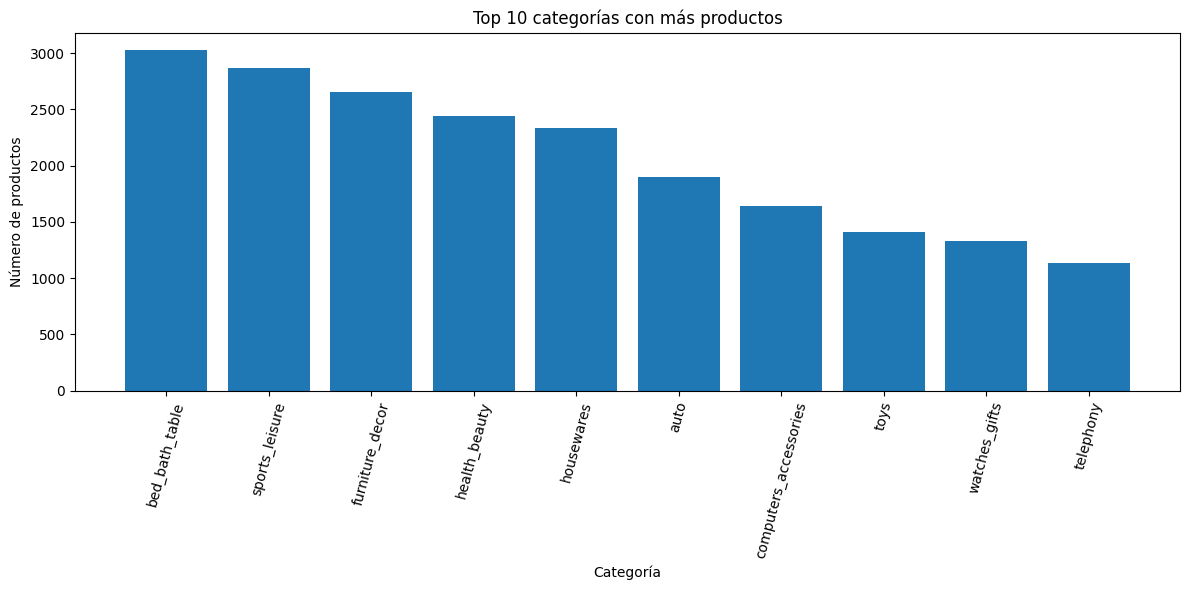

In [14]:
top_10_categorias = categorias_productos.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_10_categorias["product_category_name_english"], top_10_categorias["numero_productos"])
plt.xticks(rotation=75)
plt.title("Top 10 categorías con más productos")
plt.xlabel("Categoría")
plt.ylabel("Número de productos")
plt.tight_layout()
plt.show()

In [15]:
items_con_categoria = order_items.merge(
    products[["product_id", "product_category_name", "product_category_name_english"]],
    on="product_id",
    how="left"
)

items_con_categoria.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In [16]:
valor_orden_categoria = (
    items_con_categoria.dropna(subset=["product_category_name_english"])
    .groupby(["product_category_name_english", "order_id"])["price"]
    .sum()
    .reset_index(name="valor_orden_categoria")
)

ticket_promedio_categoria = (
    valor_orden_categoria
    .groupby("product_category_name_english")["valor_orden_categoria"]
    .mean()
    .reset_index(name="ticket_promedio")
    .sort_values(by="ticket_promedio", ascending=False)
)

ticket_promedio_categoria["ticket_promedio"] = ticket_promedio_categoria["ticket_promedio"].round(2)
ticket_promedio_categoria.head(20)

,product_category_name_english,ticket_promedio
14,computers,1231.84
64,small_appliances_home_oven_and_coffee,632.61
45,home_appliances_2,484.26
0,agro_industry_and_commerce,398.52
56,musical_instruments,304.93
63,small_appliances,302.62
34,fixed_telephony,274.58
19,construction_tools_safety,242.78
1,air_conditioning,217.49
57,office_furniture,215.21


In [17]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [18]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64